In [145]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [110]:
df = pd.read_csv("movie_reviews_with_sentiments.csv")

In [111]:
df.head()

,movie,review,cleaned_review,sentiment,sentiment_label
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive,1
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral,2
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative,0
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive,1
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive,1


# TF-IDF model

In [112]:
X = df['cleaned_review']
y = df['sentiment_label']

In [113]:
print(y.value_counts())

sentiment_label
1    232
0     49
2     20
Name: count, dtype: int64


### train

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [115]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [116]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [117]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(240, 5000)
(61, 5000)


In [118]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [119]:
y_pred = model.predict(X_test_tfidf)

### Accuracy

In [120]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7705


### Classification_Report

In [121]:
tf_idf_report = classification_report(y_test, y_pred)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [122]:
print(tf_idf_report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.77      1.00      0.87        47
           2       0.00      0.00      0.00         4

    accuracy                           0.77        61
   macro avg       0.26      0.33      0.29        61
weighted avg       0.59      0.77      0.67        61



# BERT model

In [123]:
df.head()

,movie,review,cleaned_review,sentiment,sentiment_label
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive,1
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral,2
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative,0
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive,1
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive,1


In [124]:
from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_review'],
    df['sentiment_label'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment_label']
)

In [126]:
# bert tokenizer
model_name = "bert-base-uncased"

#load tokanizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [127]:
# tokenize the reviews
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [128]:
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

test_df = pd.DataFrame({
    'text': X_test,
    'label': y_test
})

In [129]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [130]:
# Tokenize the datasets
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/61 [00:00<?, ? examples/s]

In [131]:
# load pretrained model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [132]:
# define evaluation metrixes
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)

    return {
        'accuracy': accuracy
    }

In [133]:
# define training arguments
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [134]:
# create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [135]:
# train bert
trainer.train()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.682560,0.770492
2,No log,0.656440,0.770492
3,No log,0.645929,0.770492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=90, training_loss=0.6488429599338108, metrics={'train_runtime': 493.0232, 'train_samples_per_second': 1.46, 'train_steps_per_second': 0.183, 'total_flos': 47360415191040.0, 'train_loss': 0.6488429599338108, 'epoch': 3.0})

In [136]:
# evaluate bert
results = trainer.evaluate()

print(results)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.645929,3,0.770492


{'eval_loss': 0.6459289193153381, 'eval_accuracy': 0.7704918032786885}


In [138]:
# make predictions
predictions = trainer.predict(test_dataset)

# get predicted classes
y_pred_bert = np.argmax(
    predictions.predictions,
    axis=1
)

# get actual labels
y_true_bert = np.array(y_test)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


# Accuracy

In [139]:
bert_accuracy = accuracy_score(
    y_true_bert,
    y_pred_bert
)

print("BERT Accuracy:", bert_accuracy)

BERT Accuracy: 0.7704918032786885


In [140]:
df.head()

,movie,review,cleaned_review,sentiment,sentiment_label
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive,1
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral,2
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative,0
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive,1
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive,1


In [141]:
print(
    classification_report(
        y_true_bert,
        y_pred_bert,
        target_names=['negative', 'positive', 'neutral']
    )
)

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        10
    positive       0.77      1.00      0.87        47
     neutral       0.00      0.00      0.00         4

    accuracy                           0.77        61
   macro avg       0.26      0.33      0.29        61
weighted avg       0.59      0.77      0.67        61



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [142]:
# confusion matrix
cm = confusion_matrix(
    y_true_bert,
    y_pred_bert
)

print(cm)

[[ 0 10  0]
 [ 0 47  0]
 [ 0  4  0]]


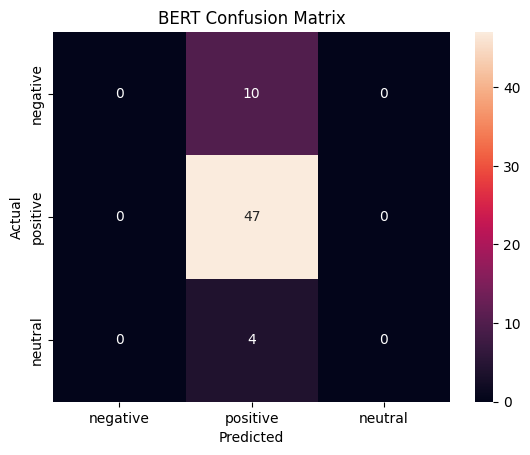

In [143]:
# visualize confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'positive', 'neutral'],
    yticklabels=['negative', 'positive', 'neutral']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")
plt.show()

## tf-idf metrics

In [146]:
tfidf_accuracy = accuracy_score(y_test, y_pred)

tfidf_precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

tfidf_recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

tfidf_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## bert metrics

In [147]:
bert_accuracy = accuracy_score(
    y_true_bert,
    y_pred_bert
)

bert_precision = precision_score(
    y_true_bert,
    y_pred_bert,
    average='weighted'
)

bert_recall = recall_score(
    y_true_bert,
    y_pred_bert,
    average='weighted'
)

bert_f1 = f1_score(
    y_true_bert,
    y_pred_bert,
    average='weighted'
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Comparison table

In [148]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],
    
    'TF-IDF': [
        tfidf_accuracy,
        tfidf_precision,
        tfidf_recall,
        tfidf_f1
    ],
    
    'BERT': [
        bert_accuracy,
        bert_precision,
        bert_recall,
        bert_f1
    ]
})

comparison

,Metric,TF-IDF,BERT
0,Accuracy,0.770492,0.770492
1,Precision,0.593658,0.593658
2,Recall,0.770492,0.770492
3,F1-Score,0.670613,0.670613


In [149]:
# display as percentages

comparison_percentage = comparison.copy()

comparison_percentage[['TF-IDF', 'BERT']] = (
    comparison_percentage[['TF-IDF', 'BERT']] * 100
)

comparison_percentage

,Metric,TF-IDF,BERT
0,Accuracy,77.049180,77.049180
1,Precision,59.365762,59.365762
2,Recall,77.049180,77.049180
3,F1-Score,67.061324,67.061324


# find best model

In [150]:
if bert_accuracy > tfidf_accuracy:
    print("BERT performed better.")
elif tfidf_accuracy > bert_accuracy:
    print("TF-IDF performed better.")
else:
    print("Both models have the same accuracy.")

Both models have the same accuracy.


In [151]:
if bert_f1 > tfidf_f1:
    print("BERT has the better F1-score.")
elif tfidf_f1 > bert_f1:
    print("TF-IDF has the better F1-score.")
else:
    print("Both models have the same F1-score.")

Both models have the same F1-score.
